# Assignment 4

>## Assignment: Quasars part II

You measure the position of a quasar $N$ times with the *same* telescope i.e. errors are homoscedastic (same for all measurements). Let's say the underlying process is Gaussian, the true position is $\mu = 1$ (in suitable units), and the errors are $\sigma=0.2$


In [14]:
#Importing Libraries

import numpy as np 
import scipy.stats as stas 
import matplotlib.pyplot as plt
import astroML 

### Part 1

- Generate fake measurements. Treat each of these observations as an estimate of the true distribution. So we'll center a Gaussian (with the known $\sigma$) at each point. This is the probability of each data point, $p(x_i|\mu,\sigma)$.
- Plot each of the individual likelihoods separately.  Also plot their product (i.e. the likelihood of the dataset $\{x_i\}$). Make sure the x grid has enough points.
- Just read off the maximum likelihood solution (e.g. using `np.argsort`). 
- Compare it with the MLE estimator derived above.

C:\Users\Renzovm\AppData\Local\Temp\ipykernel_23460\1701905928.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


MLE for the mean: 0.9998293939322389, the true mean is: 1
The error was 0.00017.
The likelihood of the measurements is: 1.2192188955513718e+76.


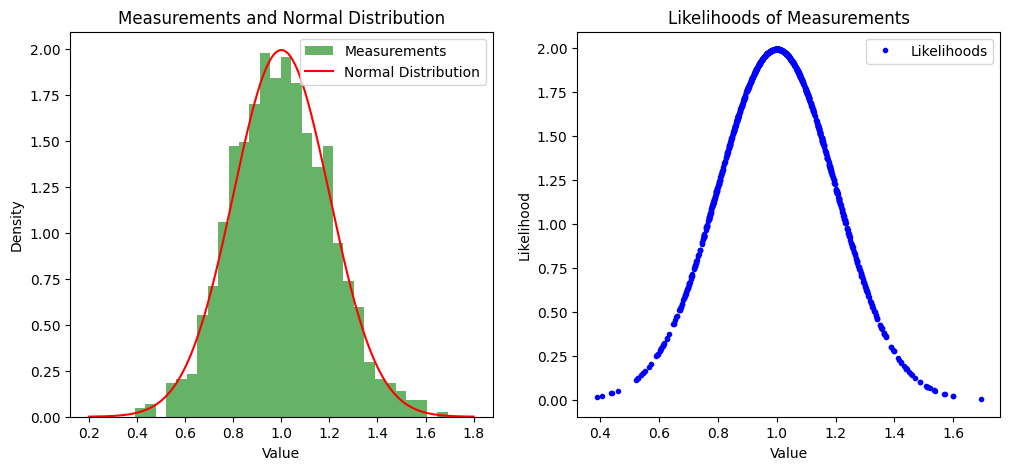

In [28]:
#Setting parameters for the normal distribution and generating measurements
sigma = 0.2
mean = 1
N_samples = 1000

#Generating measurements from a normal distribution and calculating likelihoods
measurements = np.random.normal(mean, sigma, N_samples)
normal_dist = stas.norm(loc=mean, scale=sigma)
likelihoods = normal_dist.pdf(measurements)
likelihood_measurements = np.prod(likelihoods)

x = np.linspace(mean - 4*sigma, mean + 4*sigma, 1000)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plotting the histogram of measurements and the normal distribution
ax[0].hist(measurements, bins=30, density=True, alpha=0.6, color='g', label='Measurements')
ax[0].plot(x, normal_dist.pdf(x), 'r-', label='Normal Distribution')
ax[0].set_title('Measurements and Normal Distribution')
ax[0].set_xlabel('Value')
ax[0].set_ylabel('Density')
ax[0].legend()

#Plotting the likelihoods
ax[1].plot(measurements, likelihoods, 'b.', label='Likelihoods')
ax[1].set_title(f'Likelihoods of Measurements')
ax[1].set_xlabel('Value')
ax[1].set_ylabel('Likelihood')
ax[1].legend()

fig.show()

#Getting the maximum likelihood estimate (MLE) for the mean
mesurement_max_likelihood = np.argsort(likelihoods)[-1]
print(f"MLE for the mean: {measurements[mesurement_max_likelihood]}, the true mean is: {
    mean}\nThe error was {np.round(abs(measurements[mesurement_max_likelihood] -
     mean), 5)}.\nThe likelihood of the measurements is: {np.round(likelihood_measurements, 1)}.")

### Part 2

Check if the Fisher matrix error estimate makes sense
- do a rough $2^\mathrm{nd}$ order differentiation of our log-likelihood function with `np.diff`, 
- divide through by our $\Delta \theta^2$ to get the correct normalization, 
- multiply by $-1$, 
- then take the square root.
- Compare with the Fisher matrix error derived above.
- Plot a Gaussian at the measured $\mu$ with this error as the scale to see if it matches the numerical likelihood distribution. (The normalization won't be captured, you can rescale it as you like to check it agrees).


### Part 3

Let's make our model more realistic. Our $N$ measurements were taken in different nights, where the sky behaved differently (i.e. errors are heteoscedastic). Let's assume that each measurement has a $\sigma_i$ that is normally distributed with mean $0.2$ and standard deviation $0.05$

- Generalize your code from above to this case
